# Stochastic evolution of a colony of B cells

In [1]:
import matplotlib.pyplot as plt
from stochastic_simul import simulate_gc_with_ancestry, trace_lineages

import numpy as np
from numpy.random import default_rng
import pandas as pd
from collections import defaultdict
import matplotlib.ticker as mtick
from mpl_toolkits.axes_grid1 import make_axes_locatable  
from matplotlib.lines import Line2D
from matplotlib.patches import Patch



# Fit of experimental data

In [2]:
db = pd.read_csv("../data/cdr_site_effects.csv")
cdr_positions_relative = db["cdr_positions_relative"].to_numpy()
cdr_positions = db["cdr_positions"].to_numpy()
db


,cdr_positions,cdr_positions_relative,annotation,mu,sigma
0,25,0,CDRH1,0.221032,0.533178
1,26,1,CDRH1,1.263898,0.740495
2,27,2,CDRH1,0.169602,0.198641
3,28,3,CDRH1,-0.712051,0.917131
4,29,4,CDRH1,-0.307315,0.780671
5,30,5,CDRH1,-0.052946,0.146603
6,31,6,CDRH1,-1.510187,1.195768
7,32,7,CDRH1,-3.144953,2.790815
8,49,8,CDRH2,-1.984016,1.912978
9,50,9,CDRH2,0.098357,0.227288


In [3]:


N_SEEDS = 10 
c=170
def C_schedule(r):
    return np.array([c])




# List to store mean total affinity (sum(h_i)) for each simulation round (Shape: (10, T+1))
all_sim_mean_sum_hi = [] 
# List to store mean h_i per position for each simulation (Shape: (10, T+1, N_h))
all_sim_mean_hi_per_time = [] 
# Initialize storage for all seeds
all_sim_mean_sum_hi = []
all_sim_mean_hi_per_time = []

for seed in range(N_SEEDS):
    # Run the simulation 
    history = simulate_gc_with_ancestry(
        C_schedule        = C_schedule,
        seed              = seed + 1
    )

    # Extract N_h from the 'pop' array of the first frame
    N_h = history[0]['pop'].shape[1]
    
    # Trackers for the current simulation
    current_sim_mean_sum_hi = []
    mean_hi_per_time_single_sim = np.zeros((len(history), N_h))

    for t, frame in enumerate(history):
        pop = frame['pop'] # Extract the population array from the dictionary
        
        if pop.size == 0:
            # Handle empty population for both metrics
            current_sim_mean_sum_hi.append(np.nan)
            mean_hi_per_time_single_sim[t, :] = np.nan
        else:
            # Fill NaNs with 0.0 to treat unmutated positions as 0 affinity contribution
            # This ensures we calculate the mean over the *entire* population
            pop_filled = np.nan_to_num(pop, nan=0.0)

            sum_hi_per_cell = pop_filled.sum(axis=1) 
            current_sim_mean_sum_hi.append(sum_hi_per_cell.mean())
            
            mean_hi_per_time_single_sim[t, :] = pop_filled.mean(axis=0)

    all_sim_mean_sum_hi.append(current_sim_mean_sum_hi)
    all_sim_mean_hi_per_time.append(mean_hi_per_time_single_sim)
    
    print(f"Simulation with seed={seed + 1} completed.")


sim_sum_hi_array = np.array(all_sim_mean_sum_hi) 

# Calculate the mean and standard deviation across the N_SEEDS simulations for plotting
sim_mean_agg = np.nanmean(sim_sum_hi_array, axis=0) 
sim_std_agg = np.nanstd(sim_sum_hi_array, axis=0) 

#print affinities at last step
print("\nTotal Affinity Tracking (sum(h_i)) at final step:")
print(sim_sum_hi_array[:, -1])  # Print the final step values for all simulations


times = np.arange(len(history))

print("\nTotal Affinity Tracking (sum(h_i))")
print(f"Aggregated Mean: {sim_mean_agg}")
print(f"Aggregated STD: {sim_std_agg}")

Simulation with seed=1 completed.
Simulation with seed=2 completed.
Simulation with seed=3 completed.
Simulation with seed=4 completed.
Simulation with seed=5 completed.
Simulation with seed=6 completed.
Simulation with seed=7 completed.
Simulation with seed=8 completed.
Simulation with seed=9 completed.
Simulation with seed=10 completed.

Total Affinity Tracking (sum(h_i)) at final step:
[5.28602487 9.40707749 5.24889627 5.3377925  9.97312193 4.98014525
 7.91883391 6.89680594 6.40535169 6.92551712]

Total Affinity Tracking (sum(h_i))
Aggregated Mean: [-2.80759706e-06 -1.19873993e-06  3.33923816e-03  7.83027052e-03
  1.95204887e-02  3.05863207e-02  4.49848249e-02  6.47422103e-02
  8.44898777e-02  1.12787967e-01  1.43222332e-01  1.74526673e-01
  2.13629603e-01  2.53464484e-01  3.02558411e-01  3.62702837e-01
  4.29524266e-01  5.09183952e-01  5.88784206e-01  6.80189499e-01
  7.85235144e-01  9.03548080e-01  1.03215164e+00  1.16185776e+00
  1.29242432e+00  1.43720198e+00  1.57263781e+00  1.

<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
C:\Users\maria\AppData\Local\Temp\ipykernel_28448\700445947.py:25: SyntaxWarning: invalid escape sequence '\p'
  label="$\pm$1 STD (across 10 seeds)"


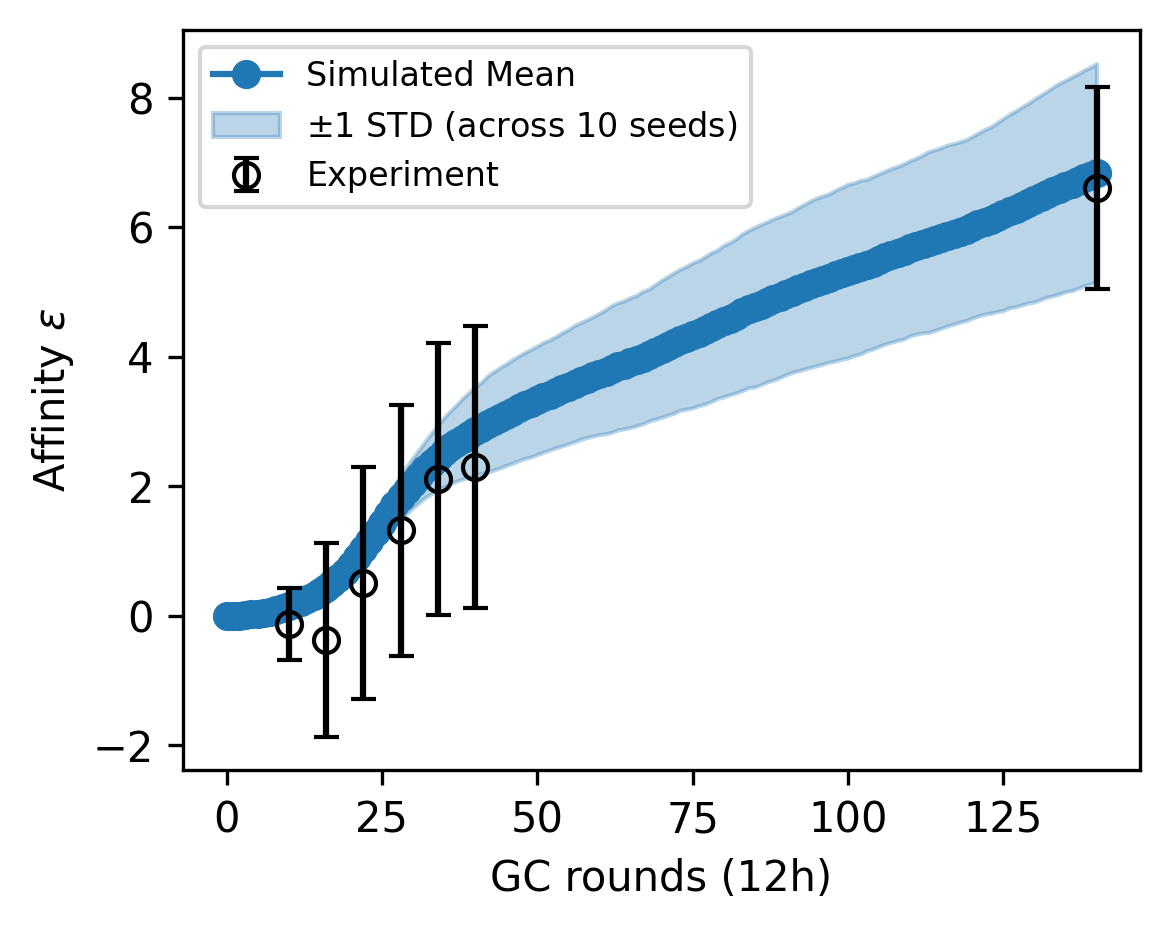

In [4]:
df_mat = (pd.read_csv("../data/data.csv", keep_default_na=False)
         [["time (days)", "delta_bind_CGG"]]
         .rename(columns={"time (days)": "t", "delta_bind_CGG": "x"}))

df_mat["t"] = df_mat["t"] * 2.0         # days -> 12h
df_mat["x"] = df_mat["x"] * np.log(10.0)  # log scale

times_exp = np.sort(df_mat.t.unique())
exp_mean = (df_mat.groupby("t")["x"]
                .mean()
                .reindex(times_exp)
                .values)
exp_std = (df_mat.groupby("t")["x"].std()
               .reindex(times_exp)
               .fillna(0.0)
               .values)
plt.figure(figsize=(4, 3.2), dpi=300)
plt.plot(times, sim_mean_agg, marker='o', color='C0', label="Simulated Mean")
plt.fill_between(
    times,
    sim_mean_agg - sim_std_agg,
    sim_mean_agg + sim_std_agg,
    color='C0',
    alpha=0.3,
    label="$\pm$1 STD (across 10 seeds)"
)

# Plot the experimental data
plt.errorbar(times_exp, exp_mean, yerr=exp_std,
             fmt='o', mfc='none', ecolor='k', color='k',
             capsize=3, label='Experiment')

plt.xlabel("GC rounds (12h)")
plt.ylabel(r"Affinity $\epsilon$")
# plt.title("Model affinity maturation (10 Replicates)")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()



In [5]:


sim_hi_array = np.array(all_sim_mean_hi_per_time) 

mean_hi_per_time_avg = np.nanmean(sim_hi_array, axis=0)

# Define times of interest (in 12h rounds)
times_of_interest = np.array([5, 8, 11, 14, 17, 20, 70]) * 2

N_h = mean_hi_per_time_avg.shape[1]

records = []

for i in range(N_h):
    position_label = cdr_positions[i] 
    
    for t in times_of_interest:
        if t < len(mean_hi_per_time_avg):
            records.append({
                "position": position_label,
                "time": t,
                "mean_hi": mean_hi_per_time_avg[t, i]
            })

df_out = pd.DataFrame(records)

# Save to CSV
df_out.to_csv("mean_hi_stochastic.csv", index=False)
print(f"\nSaved mean h_i values (averaged over {N_SEEDS} simulations) for {len(records)} entries to mean_hi_stochastic.csv")


Saved mean h_i values (averaged over 10 simulations) for 280 entries to mean_hi_stochastic.csv


# Lineage reconstruction

In [ ]:

print("Simulating...")
history = simulate_gc_with_ancestry(
        C_schedule        = C_schedule,
        seed              = 9
    )

last_frame = history[-1]
final_pop = last_frame['pop']

final_affinities = np.sum(np.nan_to_num(final_pop, nan=0.0), axis=1)
print('mean', final_affinities.mean())


Simulating...
mean 6.40535169002763


Simulation ended with 2500 cells.
Found 110 cells with 9.5 <= affinity < 10.5.


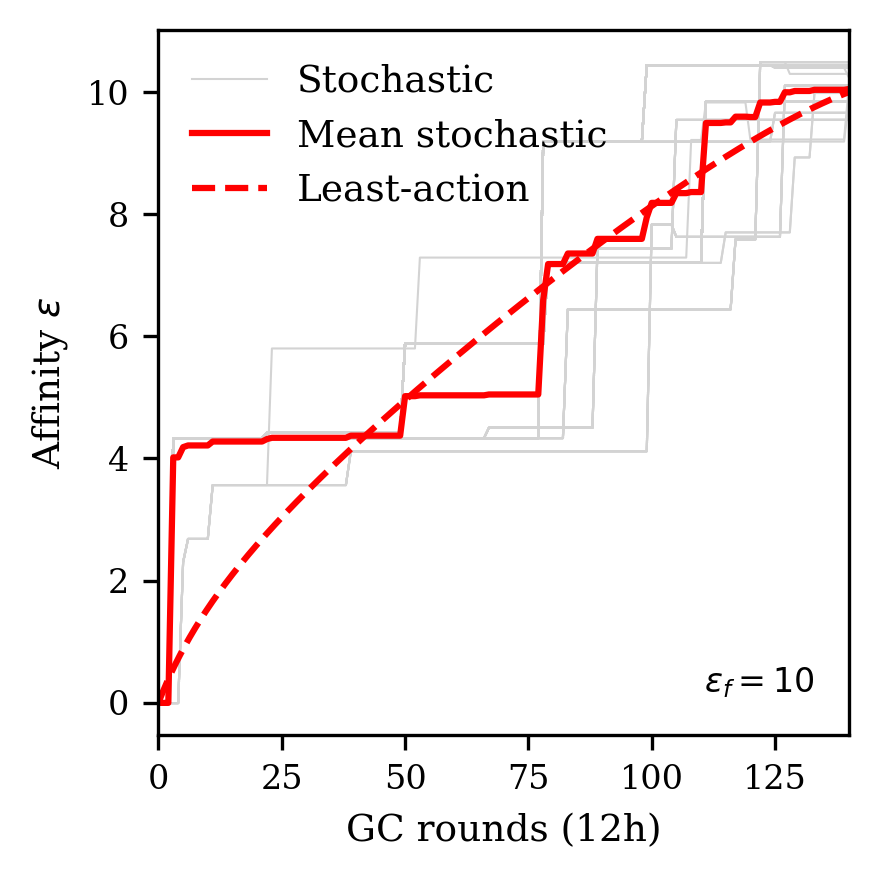

In [ ]:
target=10
target_indices = np.where((final_affinities >= target - 0.5) & (final_affinities < target + 0.5))[0]
T_steps=140
print(f"Simulation ended with {len(final_pop)} cells.")
print(f"Found {len(target_indices)} cells with {target - 0.5} <= affinity < {target + 0.5}.")

# 2. Get Trajectories
trajectories = trace_lineages(history, target_indices)
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 4,
    "figure.figsize": (3., 3.),  # ≈8.6 cm × 6.6 cm
    "figure.dpi": 300,
    "font.family": "serif",        # Often preferred in papers
})

try:
    # Try loading the file if it exists
    h_sol = np.loadtxt("../PDE/trajectory_h_140/trajectory_h_140_"+str(target)+".csv")
    T = T_steps
    n_points = len(h_sol)
    t_sol = np.linspace(0, T, n_points)
except OSError:
    # Fallback if file not found (allows script to run without file)
    h_sol = None
    t_sol = None
    T = T_steps

# --- Prepare B-cell lineage trajectories ------------------------------
h1_by_round = defaultdict(list)
fig, ax = plt.subplots()
first = True

# Map existing 'trajectories' list to the logic structure requested
for traj in trajectories:
    h1 = traj.flatten() # 1D antigen assumption
    rounds = np.arange(len(h1))

    for t, h in zip(rounds, h1):
        h1_by_round[t].append(h)
    
    if first:
        ax.plot(rounds, h1, lw=0.5, color='lightgrey', label='Stochastic')
        first = False
    else:
        ax.plot(rounds, h1, lw=0.5, color='lightgrey')

# --- Plot mean trajectory in blue -------------------------------------
if h1_by_round:
    common_rounds = sorted(h1_by_round.keys())
    mean_h1 = [np.mean(h1_by_round[t]) for t in common_rounds]
    ax.plot(common_rounds, mean_h1, lw=1.5, color='red', label='Mean stochastic')

# --- Plot least-action trajectory in red ------------------------------
if h_sol is not None:
    ax.plot(t_sol, h_sol, lw=1.5, color='red', label='Least-action', linestyle='--')

t_max = T_steps
ax.set_xlim(0, t_max)
ax.set_xlabel("GC rounds (12h)")
ax.set_ylabel(r"Affinity $\epsilon$")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
ax.text(0.95, 0.05, r"$\epsilon_f = 10$", transform=ax.transAxes, ha='right', va='bottom', fontsize=8)
plt.show()


Target 3: Found 3 cells.
Target 7: Found 364 cells.
Target 10: Found 110 cells.


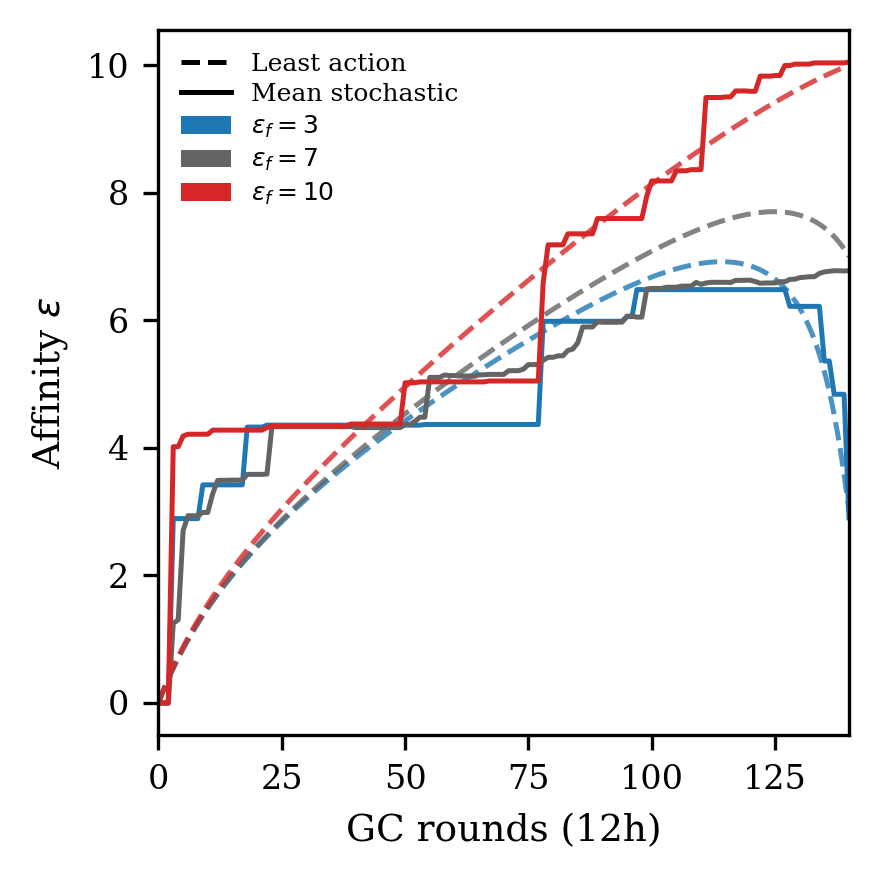

In [ ]:


plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 4,
    "figure.figsize": (3., 3.),
    "figure.dpi": 300,
    "font.family": "serif",
})

targets = [3,7,10]


colors = [plt.cm.coolwarm(x) for x in np.linspace(0.9, 0.1, len(targets))]
colors = [ '#1f77b4',  "#656464",'#d62728']
fig, ax = plt.subplots()

for i, (t_val, color) in enumerate(zip(targets, colors)):
    # --- Identify Stochastic Indices ---
    target_indices = np.where((final_affinities >= t_val - 0.5) & (final_affinities < t_val + 0.5))[0]
    print(f"Target {t_val}: Found {len(target_indices)} cells.")

    # --- Plot Least-action (Theory) ---
    try:
        # Note: T_steps must be defined in your previous context
        h_sol = np.loadtxt(f"../PDE/trajectory_h_140/trajectory_h_140_{t_val}.csv", delimiter=",")
        n_points = len(h_sol)
        t_sol = np.linspace(0, T_steps, n_points)
        
        # Plot
        ax.plot(t_sol, h_sol, lw=1.2, linestyle='--', color=color, alpha=0.8)
    except OSError:
        print(f"Warning: Could not load trajectory file for target {t_val}")

    # --- Plot Mean Stochastic (Simulation) ---
    if len(target_indices) > 0:
        trajectories = trace_lineages(history, target_indices)
        
        h1_by_round = defaultdict(list)
        for traj in trajectories:
            h1 = traj.flatten()
            rounds = np.arange(len(h1))
            for r, h in zip(rounds, h1):
                h1_by_round[r].append(h)
        
        if h1_by_round:
            common_rounds = sorted(h1_by_round.keys())
            mean_h1 = [np.mean(h1_by_round[r]) for r in common_rounds]
            
            # Plot
            ax.plot(common_rounds, mean_h1, lw=1.2, linestyle='-', color=color)

legend_elements = [
    # Line styles (Black)
    Line2D([0], [0], color='black', lw=1.2, linestyle='--', label='Least action'),
    Line2D([0], [0], color='black', lw=1.2, linestyle='-', label='Mean stochastic'),
    
    # Target Colors (Rectangles) - Dynamic reference to the colors list
    Patch(facecolor=colors[0], edgecolor='none', label=rf'$\epsilon_f={targets[0]}$'),
    Patch(facecolor=colors[1], edgecolor='none', label=rf'$\epsilon_f={targets[1]}$'),
    Patch(facecolor=colors[2], edgecolor='none', label=rf'$\epsilon_f={targets[2]}$'),
]

ax.set_xlim(0, T_steps)
ax.set_xlabel("GC rounds (12h)")
ax.set_ylabel(r"Affinity $\epsilon$")

# Add the custom legend
ax.legend(handles=legend_elements, frameon=False, loc="upper left", fontsize=6, labelspacing=0.3)

fig.tight_layout()
plt.show()


# Histograms stochastic vs PDE

Simulating for c=50...
Final population size for c=50: 2500
11.12893027270573
rho_fp [1.15999942e-50 4.14463669e-50 1.76962447e-49 7.57016821e-49
 3.21223078e-48 1.35138543e-47 5.63683309e-47 2.33131002e-46
 9.56096224e-46 3.88838453e-45 1.56831521e-44 6.27372480e-44
 2.48930175e-43 9.79764933e-43 3.82552261e-42 1.48189057e-41
 5.69546654e-41 2.17200459e-40 8.21939322e-40 3.08669943e-39
 1.15040545e-38 4.25533990e-38 1.56231002e-37 5.69338779e-37
 2.05950962e-36 7.39542678e-36 2.63623273e-35 9.32906139e-35
 3.27745204e-34 1.14310817e-33 3.95819546e-33 1.36072510e-32
 4.64418136e-32 1.57367131e-31 5.29399582e-31 1.76813219e-30
 5.86276653e-30 1.92992632e-29 6.30697462e-29 2.04613426e-28
 6.58974932e-28 2.10675017e-27 6.68579257e-27 2.10607363e-26
 6.58504666e-26 2.04357939e-25 6.29438193e-25 1.92408421e-24
 5.83692219e-24 1.75715871e-23 5.24907477e-23 1.55587847e-22
 4.57578103e-22 1.33513762e-21 3.86484194e-21 1.10982656e-20
 3.16131695e-20 8.93185170e-20 2.50291217e-19 6.95584008e-19


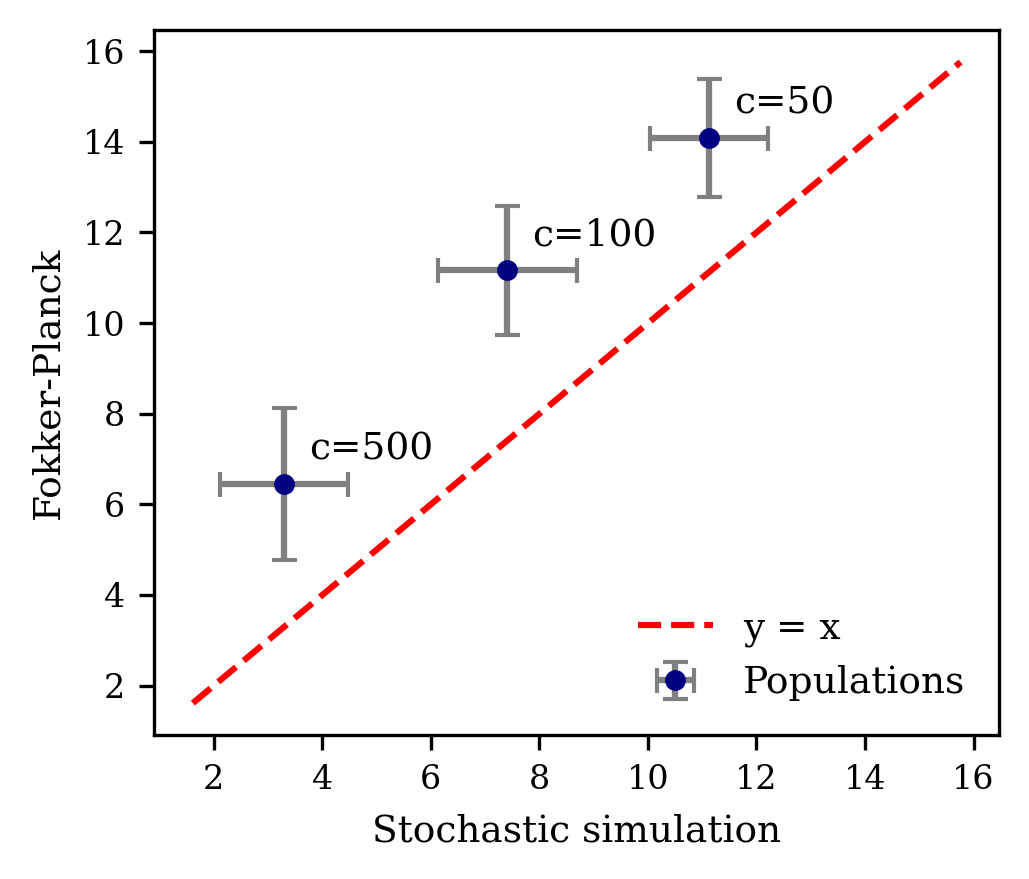

In [ ]:
c_array = [50, 100, 500]

stoch_means, stoch_stds = [], []
fp_means, fp_stds = [], []
valid_c = []
dead_c_info = []

for c in c_array:
    def C_schedule(r): return np.array([c])
    
    # Run Simulation
    print(f"Simulating for c={c}...")
    history = simulate_gc_with_ancestry(
   
        C_schedule=C_schedule,   
     
        mutable_positions=cdr_positions_relative, 
        seed=1                   
    )
    
    final_frame = history[-1]
    final_pop = final_frame['pop']

    final_affinities = np.sum(np.nan_to_num(final_pop, nan=0.0), axis=1)
    
    print(f"Final population size for c={c}: {len(final_affinities)}")
    print(final_affinities.mean())


    # Load the csv of results from fokker planck
    fp_filename = f'../PDE/rho_epsilon_last_step/rho_epsilon_last_step_c={c}.csv'
    try:
        df_fp = pd.read_csv(fp_filename)
        eps_fp = df_fp['epsilon'].values
        rho_fp = df_fp['rho_epsilon'].values
    except FileNotFoundError:
        eps_fp, rho_fp = np.array([]), np.array([])

    # 3. Check for dead populations
    stoch_dead = len(final_affinities) == 0
    fp_dead = len(rho_fp) == 0 or not np.sum(rho_fp) > 1 
    print('rho_fp', rho_fp)

    if stoch_dead or fp_dead:
        if stoch_dead and fp_dead:
            status = "Dead"
        elif stoch_dead:
            status = "Stoch Dead"
        else:
            status = "FP Dead"
        
        dead_c_info.append(f"c={c}: {status}")
        continue  # Skip plotting points for dead populations

    stoch_means.append(np.mean(final_affinities))
    stoch_stds.append(np.std(final_affinities))

    total_mass = np.sum(rho_fp)
    mean_fp = np.sum(eps_fp * rho_fp) / total_mass
    
    # Variance = E[X^2] - (E[X])^2
    var_fp = np.sum((eps_fp**2) * rho_fp) / total_mass - (mean_fp**2)
    std_fp = np.sqrt(max(0, var_fp)) 

    fp_means.append(mean_fp)
    fp_stds.append(std_fp)
    valid_c.append(c)


# ---------------------- Plotting ----------------------
plt.figure(figsize=(3.5, 3), dpi=300)

if valid_c:
    # Scatter plot with double error bars
    plt.errorbar(
        stoch_means, fp_means, 
        xerr=stoch_stds, yerr=fp_stds, 
        fmt='o', color='navy', ecolor='gray', capsize=3, label='Populations'
    )
    
    # Annotate each point with its concentration
    for i, c in enumerate(valid_c):
        plt.annotate(
            f"c={c}", 
            (stoch_means[i], fp_means[i]), 
            textcoords="offset points", 
            xytext=(6, 6), 
            ha='left', 
            fontsize=9
        )

    # Add reference line y = x to show perfect agreement
    min_val = min(min(stoch_means), min(fp_means)) - max(max(stoch_stds), max(fp_stds))
    max_val = max(max(stoch_means), max(fp_means)) + max(max(stoch_stds), max(fp_stds))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=1.5, label='y = x')

# If any populations died, list them in a text box on the graph
if dead_c_info:
    text_str = dead_c_info[0]
    plt.gca().text(
        0.75, 0.95, text_str, 
        transform=plt.gca().transAxes,
        fontsize=8, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='mistyrose', edgecolor='red', alpha=0.7)
    )

plt.xlabel("Stochastic simulation")
plt.ylabel("Fokker-Planck")
# plt.title("Affinity Comparison (Stochastic vs FP)")

plt.legend(frameon=False, loc='lower right')
# plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()


--- Simulating for c=1.0 ---
Stochastic final population size: 0
Fokker-Planck total population: 0.00
Fokker-Planck mean affinity: 39.57

--- Simulating for c=21.544346900318832 ---
Stochastic final population size: 2500
Stochastic mean affinity: 16.53
Fokker-Planck total population: 2500.47
Fokker-Planck mean affinity: 18.76

--- Simulating for c=464.15888336127773 ---
Stochastic final population size: 2500
Stochastic mean affinity: 4.35
Fokker-Planck total population: 2501.17
Fokker-Planck mean affinity: 6.62

--- Simulating for c=10000.0 ---
Stochastic final population size: 2500
Stochastic mean affinity: 0.40
Fokker-Planck total population: 2501.37
Fokker-Planck mean affinity: 1.06


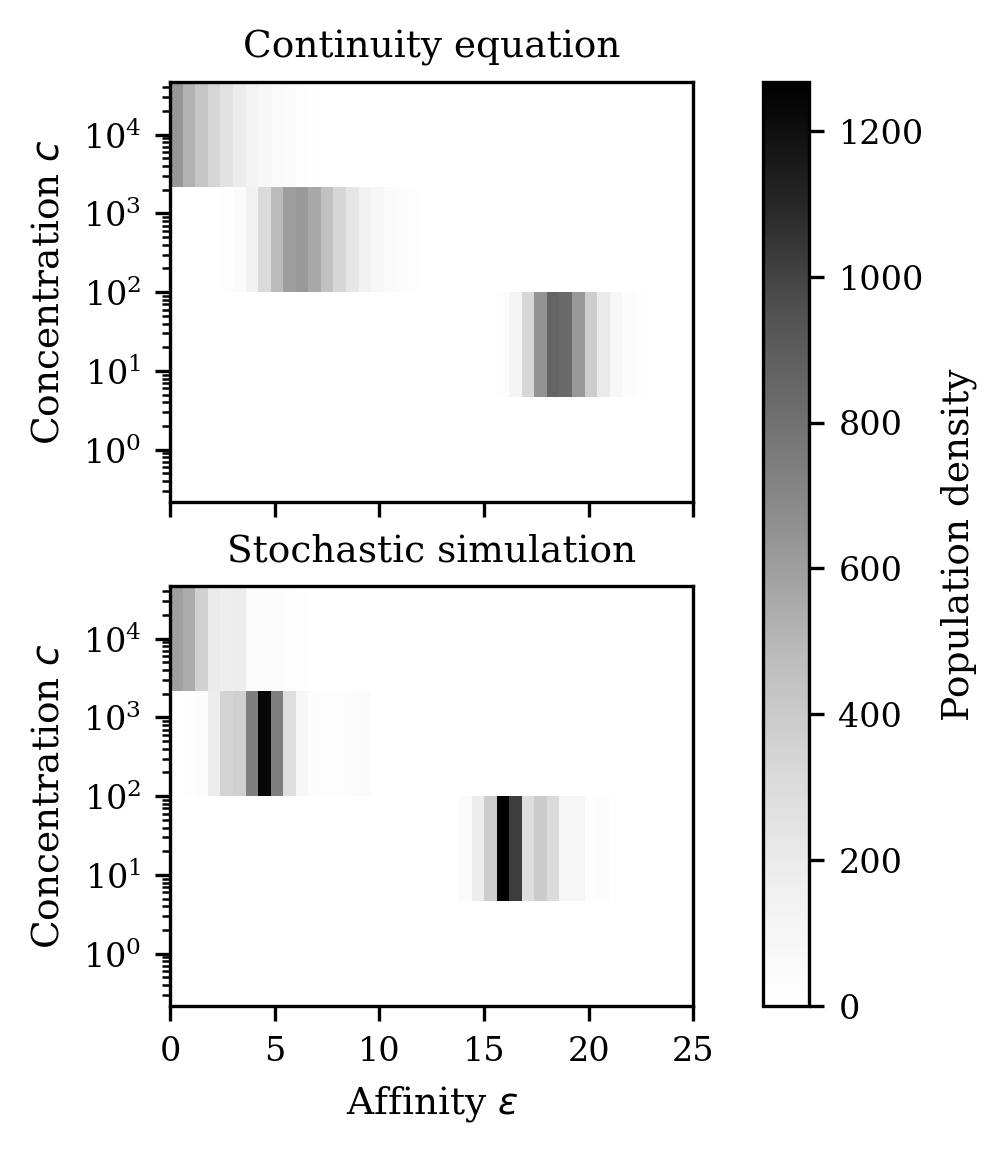

In [ ]:
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 4,
    "figure.figsize": (3., 4.0), 
    "figure.dpi": 300,
    "font.family": "serif",
})

seed=0

c_array = np.logspace(0, 4, 4)

num_eps_bins = 50  # Increased resolution for the wider range
eps_bins = np.linspace(0, 30, num_eps_bins + 1)
eps_centers = 0.5 * (eps_bins[:-1] + eps_bins[1:])
bin_width = eps_bins[1] - eps_bins[0]

# Rows = concentration (c), Columns = affinity (epsilon)
stoch_density_matrix = np.zeros((len(c_array), num_eps_bins))
fp_density_matrix = np.zeros((len(c_array), num_eps_bins))

for i, c in enumerate(c_array):
    print(f"\n--- Simulating for c={c} ---")
    def C_schedule(r): return np.array([c])

    history = simulate_gc_with_ancestry(

        C_schedule=C_schedule,   
      
        mutable_positions=cdr_positions_relative, 
        seed=0,                   

    )
    
    # Extract the final state from history
    final_frame = history[-1]
    final_pop = final_frame['pop']

    # Calculate total affinities for the final population
    final_affinities = np.sum(np.nan_to_num(final_pop, nan=0.0), axis=1)
    
    stoch_pop_size = len(final_affinities)
    print(f"Stochastic final population size: {stoch_pop_size}")
    if stoch_pop_size > 0:
        print(f"Stochastic mean affinity: {final_affinities.mean():.2f}")

    # Calculate absolute stochastic density: Counts / bin_width
    counts, _ = np.histogram(final_affinities, bins=eps_bins)
    stoch_abs_density = counts / bin_width
    stoch_density_matrix[i, :] = stoch_abs_density

    # Load the csv of results from fokker planck
    fp_filename = f'../PDE/rho_epsilon_last_step/rho_epsilon_last_step_c={c}.csv'
    df_fp = pd.read_csv(fp_filename)
    eps_fp = df_fp['epsilon'].values
    rho_fp = df_fp['rho_epsilon'].values

    # Calculate absolute Fokker-Planck density
    deps_fp = eps_fp[1] - eps_fp[0]
    fp_abs_density = rho_fp / deps_fp
    
    fp_pop_size = np.sum(rho_fp)  # Total area under the curve
    print(f"Fokker-Planck total population: {fp_pop_size:.2f}")
    
    # Calculate and print the mean affinity from the Fokker-Planck distribution
    if fp_pop_size > 0:
        fp_mean_affinity = np.sum(eps_fp * rho_fp) / fp_pop_size
        print(f"Fokker-Planck mean affinity: {fp_mean_affinity:.2f}")

    # Interpolate absolute Fokker-Planck density onto the exact same affinity grid.
    fp_interp = np.interp(eps_centers, eps_fp, fp_abs_density, left=0.0, right=0.0)
    
    # Ensure it's exactly 0 if population is practically dead (less than 1 individual)
    if fp_pop_size < 1.0:
        fp_interp = np.zeros_like(fp_interp)
        
    fp_density_matrix[i, :] = fp_interp

# Define the bounds for the y-axis (concentration) blocks in log space
log_c = np.log10(c_array)
dc = log_c[1] - log_c[0] if len(log_c) > 1 else 1.0
c_edges_log = np.concatenate([log_c - dc/2, [log_c[-1] + dc/2]])
c_edges = 10**c_edges_log

# Create a meshgrid for plotting (X=Affinity, Y=Concentration)
Eps_mesh, C_mesh = np.meshgrid(eps_bins, c_edges)

# Determine the absolute maximum density for shared colormap normalization
vmax = max(np.max(fp_density_matrix), np.max(stoch_density_matrix))
vmin = 0

# 2 rows, 1 column for stacked layout
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, sharey=True)

# Subplot 1: Fokker-Planck Heatmap (Top)
im1 = ax1.pcolormesh(Eps_mesh, C_mesh, fp_density_matrix, cmap='Greys', 
                     vmin=vmin, vmax=vmax, shading='flat')
ax1.set_title("Continuity equation")
ax1.set_ylabel("Concentration $c$")
ax1.set_yscale('log')
ax1.set_xlim(0, 25)

# Subplot 2: Stochastic Heatmap (Bottom)
im2 = ax2.pcolormesh(Eps_mesh, C_mesh, stoch_density_matrix, cmap='Greys', 
                     vmin=vmin, vmax=vmax, shading='flat')
ax2.set_title("Stochastic simulation")
ax2.set_xlabel(r"Affinity $\epsilon$")
ax2.set_ylabel("Concentration $c$")
ax2.set_yscale('log')
ax2.set_xlim(0, 25)

# Add a single shared colorbar spanning both axes
# Increased pad from 0.04 to 0.15 to push it further to the right
cbar = fig.colorbar(im2, ax=[ax1, ax2], fraction=0.15, pad=0.1)
cbar.set_label("Population density")

plt.show()

# Surviving probability vs C

In [ ]:
c_array = np.logspace(-1, 2, 12)  # 10 values from 1 to 1000 on a log scale

N_SEEDS = 10
survival_mean_arr = []

for c in c_array:
    def C_schedule(r): return np.array([c])
    
    print(f"Simulating for c={c} across {N_SEEDS} seeds...")
    
    c_survied = 0
    
    # Run Simulation for 10 seeds
    for seed in range(N_SEEDS):
        history = simulate_gc_with_ancestry(
            C_schedule=C_schedule,   

            seed=seed+1              
        )
        
        # Extract the final state from history
        final_frame = history[-1]
        final_pop = final_frame['pop']

        # If population is not dead, calculate and store its mean affinity
        if len(final_pop) > 0:
            c_survied += 1
    survival_mean_arr.append(c_survied / N_SEEDS)

# ---------------------- Plotting ----------------------#save the results to csv
df_survival = pd.DataFrame({
    'c': c_array,
    'survival_rate': survival_mean_arr
})

df_survival.to_csv('survival_rates_log.csv', index=False)



            
    

Simulating for c=0.1 across 10 seeds...
Simulating for c=0.1873817422860384 across 10 seeds...
Simulating for c=0.3511191734215131 across 10 seeds...
Simulating for c=0.6579332246575679 across 10 seeds...
Simulating for c=1.232846739442066 across 10 seeds...
Simulating for c=2.3101297000831593 across 10 seeds...
Simulating for c=4.328761281083057 across 10 seeds...
Simulating for c=8.111308307896868 across 10 seeds...
Simulating for c=15.199110829529332 across 10 seeds...
Simulating for c=28.48035868435799 across 10 seeds...
Simulating for c=53.36699231206307 across 10 seeds...
Simulating for c=100.0 across 10 seeds...


In [ ]:
c_array = np.logspace(-1, 2, 12)  # 10 values from 1 to 1000 on a log scale


In [ ]:
df_survival_fp = pd.read_csv('../PDE/survival_rate_fp_log.csv')
df_survival_fp

,c,rho_c,survival_rate
0,0.100000,0.000000e+00,7.577451e-140
1,0.187382,0.000000e+00,5.533853e-105
2,0.351119,0.000000e+00,1.221849e-73
3,0.657933,0.000000e+00,4.388254e-47
4,1.232847,0.000000e+00,3.683466e-26
5,2.310130,0.000000e+00,8.446664e-11
6,4.328761,0.000000e+00,1.000178e+00
7,8.111308,0.000000e+00,1.000175e+00
8,15.199111,0.000000e+00,1.000311e+00
9,28.480359,0.000000e+00,1.000262e+00


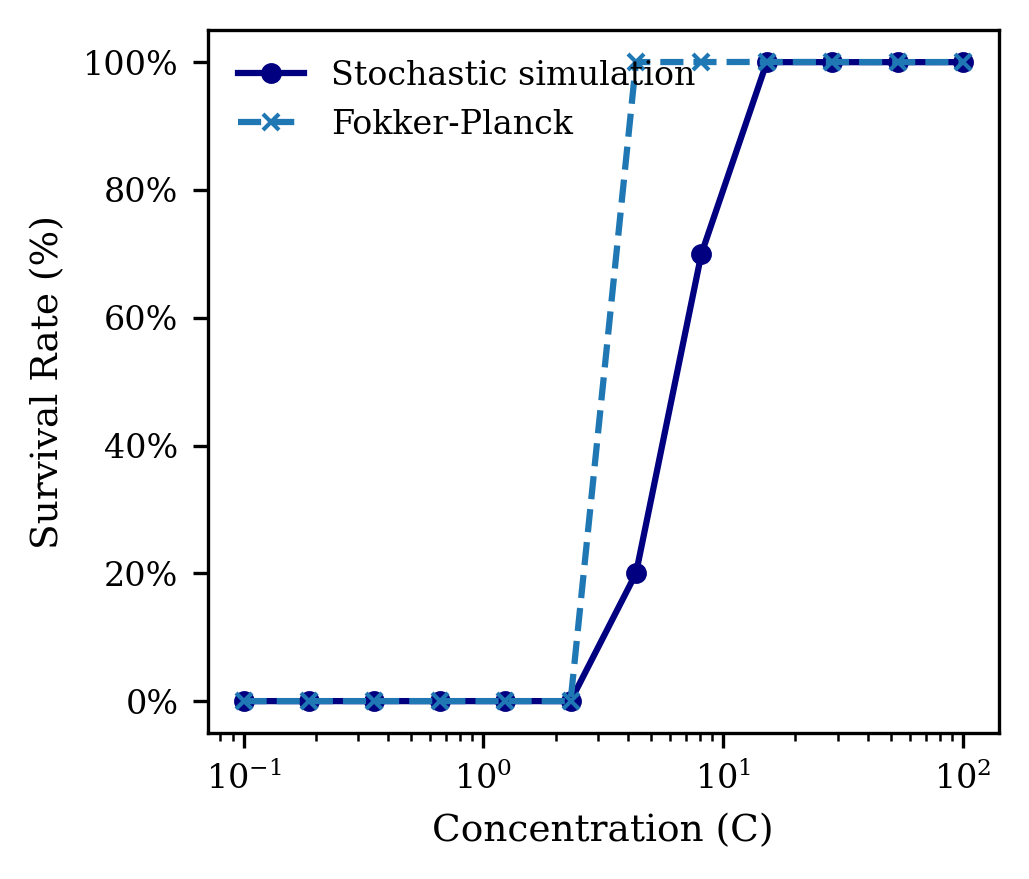

In [ ]:
plt.figure(figsize=(3.5, 3), dpi=300)

# Plot your first dataset
plt.plot(c_array, survival_mean_arr, marker='o', color='navy', label='Stochastic simulation')

# Group the Fokker-Planck dataframe by rho_c to plot a line for each parameter set
for rho_c, group in df_survival_fp.groupby('rho_c'):
    if rho_c != 0:
        continue
    # Sorting by 'c' ensures the line connects points left-to-right correctly
    group = group.sort_values(by='c')
    # plt.plot(group['c'], group['survival_rate'], marker='x', linestyle='--', label=rf'FP ($\rho_c={rho_c}$)')
    plt.plot(group['c'], group['survival_rate'], marker='x', linestyle='--', label='Fokker-Planck')


plt.xlabel("Concentration (C)")
plt.ylabel("Survival Rate (%)")
# plt.title("Survival Rate vs Antigen Concentration")
plt.xscale('log')  # Set x-axis to logarithmic scale

# Format the y-axis ticks as percentages (assuming your raw data is in fractions 0.0 to 1.0)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

plt.legend(fontsize=8, frameon=False, loc='upper left')
# plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Impact of population size

In [ ]:
N_max_array = [500, 2500, 5000]
c_array = [100, 200, 500]
colors = ['navy', 'darkorange', 'forestgreen']  # Colors for different N_max
n_seeds = 50  # Number of stochastic runs per configuration

results = {}
dead_c_info = []

for N_max_test, color in zip(N_max_array, colors):
    print(f"\n--- Running for N_max={N_max_test} ---")
    
    # Initialize storage for this specific N_max
    results[N_max_test] = {
        'stoch_means': [], 'stoch_stds': [],
        'fp_means': [], 'fp_stds': [],
        'valid_c': [], 'color': color
    }
    
    for c in c_array:
        def C_schedule(r): return np.array([c])
        
        print(f"Simulating for c={c} across {n_seeds} seeds...")
        seed_means = []
        
        # Run Simulation across multiple seeds
        for seed in range(1, n_seeds + 1):
            history = simulate_gc_with_ancestry(
                N_init=N_max_test,            
                N_max=N_max_test,             
                C_schedule=C_schedule,   
                seed=seed              
            )
            
            # 1. Extract the final state from history
            final_frame = history[-1]
            final_pop = final_frame['pop']

            # 2. Calculate total affinities for the final population
            final_affinities = np.sum(np.nan_to_num(final_pop, nan=0.0), axis=1)
            
            # Only record the mean if the population survived this specific seed
            if len(final_affinities) > 0:
                seed_means.append(final_affinities.mean())
                
        print(f"Surviving runs for N_max={N_max_test}, c={c}: {len(seed_means)}/{n_seeds}")

        # Load the csv of results from fokker planck
        fp_filename = f'../PDE/rho_epsilon_last_step/rho_epsilon_last_step_N_max={N_max_test}_c={c}.csv'
        try:
            df_fp = pd.read_csv(fp_filename)
            eps_fp = df_fp['epsilon'].values
            rho_fp = df_fp['rho_epsilon'].values
        except FileNotFoundError:
            eps_fp, rho_fp = np.array([]), np.array([])

        # 3. Check for dead populations
        # Stochastic is considered dead if ALL seeds died
        stoch_dead = len(seed_means) == 0
        fp_dead = len(rho_fp) == 0 or not np.sum(rho_fp) > 1 

        if stoch_dead or fp_dead:
            if stoch_dead and fp_dead:
                status = "Dead"
            elif stoch_dead:
                status = "Stoch Dead"
            else:
                status = "FP Dead"
            
            dead_c_info.append(f"N_max={N_max_test}, c={c}: {status}")
            continue  # Skip plotting points for dead populations

        # 4. Calculate Stochastic Moments ACROSS SEEDS
        results[N_max_test]['stoch_means'].append(np.mean(seed_means))
        results[N_max_test]['stoch_stds'].append(np.std(seed_means))

        # 5. Calculate Fokker-Planck Moments
        total_mass = np.sum(rho_fp)
        mean_fp = np.sum(eps_fp * rho_fp) / total_mass
        
        # Variance = E[X^2] - (E[X])^2
        var_fp = np.sum((eps_fp**2) * rho_fp) / total_mass - (mean_fp**2)
        # Ensure no negative variance due to floating point inaccuracies
        std_fp = np.sqrt(max(0, var_fp)) 

        results[N_max_test]['fp_means'].append(mean_fp)
        results[N_max_test]['fp_stds'].append(std_fp)
        results[N_max_test]['valid_c'].append(c)




--- Running for N_max=500 ---
Simulating for c=100 across 50 seeds...
Surviving runs for N_max=500, c=100: 50/50
Simulating for c=200 across 50 seeds...
Surviving runs for N_max=500, c=200: 50/50
Simulating for c=500 across 50 seeds...
Surviving runs for N_max=500, c=500: 50/50

--- Running for N_max=2500 ---
Simulating for c=100 across 50 seeds...
Surviving runs for N_max=2500, c=100: 50/50
Simulating for c=200 across 50 seeds...
Surviving runs for N_max=2500, c=200: 50/50
Simulating for c=500 across 50 seeds...
Surviving runs for N_max=2500, c=500: 50/50

--- Running for N_max=5000 ---
Simulating for c=100 across 50 seeds...
Surviving runs for N_max=5000, c=100: 50/50
Simulating for c=200 across 50 seeds...
Surviving runs for N_max=5000, c=200: 50/50
Simulating for c=500 across 50 seeds...
Surviving runs for N_max=5000, c=500: 50/50


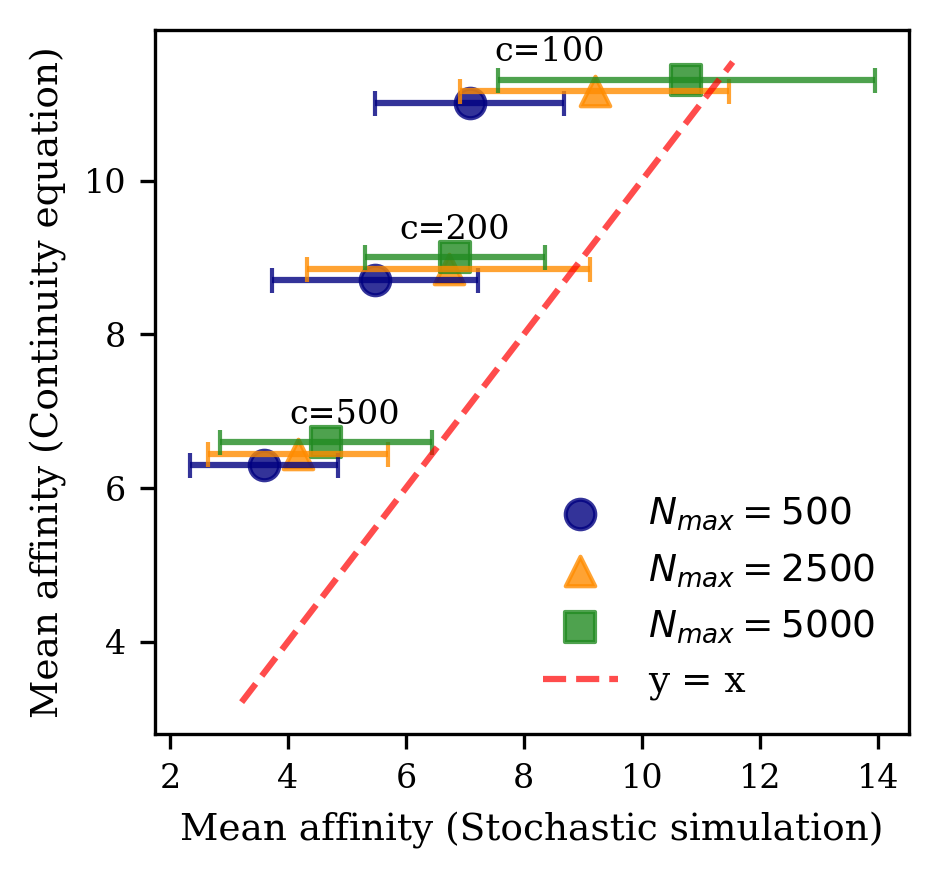

In [ ]:
plt.figure(figsize=(3.2, 3.), dpi=300)

global_min = float('inf')
global_max = float('-inf')

# Flag to ensure we only label the concentrations once
annotated_c = False

# Define different markers for each N_max (circle, triangle, square)
markers = ['o', '^', 's']

# Set a small base offset for the y-axis to prevent overlap.
# Adjust this value depending on the scale of your y-axis!
jitter_amount = 0.15 

# Iterate through the stored results to plot each N_max
for idx, N_max_test in enumerate(N_max_array):
    res = results[N_max_test]
    
    if not res['valid_c']:
        continue
        
    # Calculate a slight vertical shift based on the loop index.
    # This dynamically centers the shifts (e.g., -offset, 0, +offset for 3 items).
    offset = (idx - (len(N_max_array) - 1) / 2.0) * jitter_amount
    
    # Apply the shift to the y-coordinates
    shifted_y = [y + offset for y in res['fp_means']]
        
    # Scatter plot using the shifted y-coordinates
    plt.scatter(
        res['stoch_means'], shifted_y, 
        marker=markers[idx % len(markers)], 
        color=res['color'], 
        label=f'$N_{{max}}={N_max_test}$', 
        alpha=0.8,
        s=50  # Size of the marker
    )
    
    # Error bars applied using the shifted y-coordinates
    plt.errorbar(
        res['stoch_means'], shifted_y,
        xerr=res['stoch_stds'],
        fmt='none',           
        ecolor=res['color'],  
        alpha=0.8,
        capsize=3             
    )
    
    # Annotate each point with its concentration ONLY ONCE, in black
    if not annotated_c:
        for i, c in enumerate(res['valid_c']):
            plt.annotate(
                f"c={c}", 
                (res['stoch_means'][i], shifted_y[i]), 
                textcoords="offset points", 
                xytext=(6, 10), 
                ha='left', 
                fontsize=8,
                color='black'
            )
        annotated_c = True  # Prevent future iterations from adding text

    # Track global bounds using the ORIGINAL unshifted data 
    # to properly scale the y=x reference line
    current_min = min(min(res['stoch_means']), min(res['fp_means']))
    current_max = max(max(res['stoch_means']), max(res['fp_means']))
    global_min = min(global_min, current_min)
    global_max = max(global_max, current_max)

# Add reference line y = x to show perfect agreement
if global_min != float('inf'):
    # Add a slight padding to the bounds for the reference line so it stretches past the points
    padding = (global_max - global_min) * 0.05
    plt.plot([global_min - padding, global_max + padding], 
             [global_min - padding, global_max + padding], 
             'r--', lw=1.5, label='y = x', alpha=0.7)

# If any populations died, list them in a text box on the graph
if dead_c_info:
    # Join multiple dead population warnings with a newline
    text_str = "\n".join(dead_c_info)
    plt.gca().text(
        0.05, 0.95, text_str, # Placed on the left to avoid the legend
        transform=plt.gca().transAxes,
        fontsize=8, verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='mistyrose', edgecolor='red', alpha=0.7)
    )

plt.xlabel("Mean affinity (Stochastic simulation)")
plt.ylabel("Mean affinity (Continuity equation)")

plt.legend(frameon=False, loc='lower right')
plt.tight_layout()

plt.show()